In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.src.backend.jax.nn import categorical_crossentropy
from rich import padding
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

C:\Users\Weaam\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 469s 3us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


# Helper Function

In [9]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
    validation_data=(x_v, to_categorical(y_v, 10)),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=0)

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# 1A. Normalization Comparison

CNN Architecture

In [12]:
def BaselineCNN():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

Experiment A

In [13]:
model_a = BaselineCNN()
history_a, test_acc_a, test_loss_a, time_a = train_and_evaluate(model_a, x_train, y_train, x_val, y_val, x_test, y_test)

Test Acc: 0.5699 | Test Loss: 3.0413 | Time:434.0


Experiment B

In [17]:
x_train_minmax = x_train / 255.0
x_val_minmax = x_val / 255.0
x_test_minmax = x_test / 255.0

model_b = BaselineCNN()
history_b, test_acc_b, test_loss_b, time_b = train_and_evaluate(model_b, x_train_minmax, y_train, x_val_minmax, y_val, x_test_minmax, y_test)

Test Acc: 0.6646 | Test Loss: 1.3584 | Time:765.3


Experiment C

In [19]:
mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))

x_train_standardized = (x_train - mean) / std
x_val_standardized = (x_val - mean) / std
x_test_standardized = (x_test - mean) / std

model_c = BaselineCNN()
history_c, test_acc_c, test_loss_c, time_c = train_and_evaluate(model_c, x_train_standardized,y_train, x_val_standardized, y_val, x_test_standardized, y_test)

Test Acc: 0.6799 | Test Loss: 1.8093 | Time:913.0


Visualization

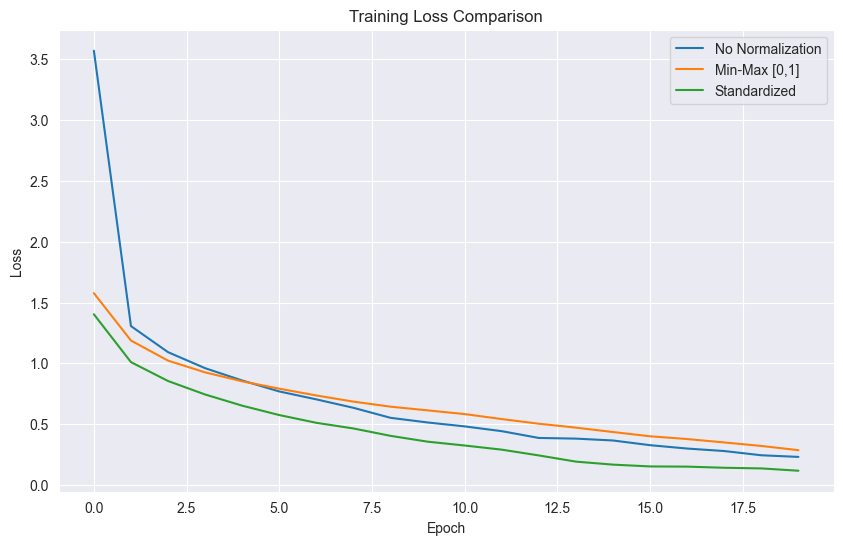

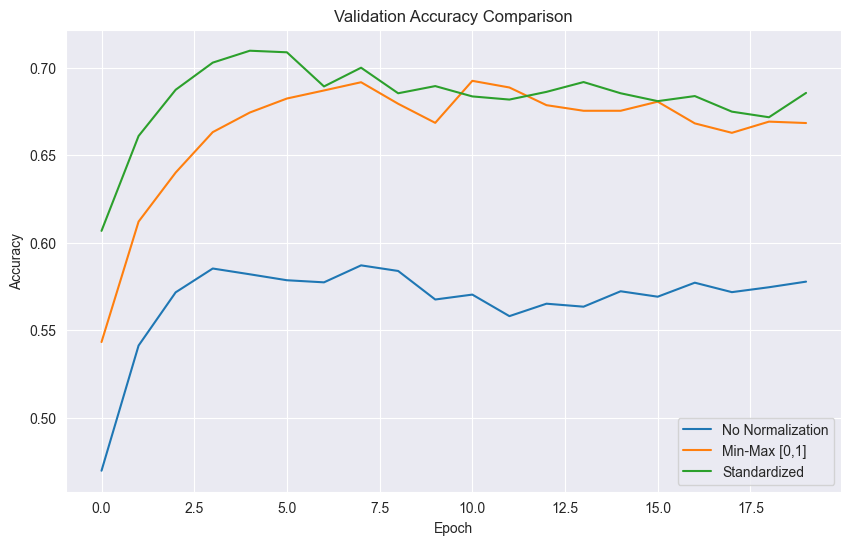

In [29]:
histories = [history_a, history_b, history_c]
plot_curves(histories, labels=['No Normalization', 'Min-Max [0,1]', 'Standardized'],
            metric='loss',
            title='Training Loss Comparison',
            ylabel='Loss')
plot_curves(histories, labels=['No Normalization', 'Min-Max [0,1]', 'Standardized'],
            metric='val_accuracy',
            title='Validation Accuracy Comparison',
            ylabel='Accuracy')

# 1B. Data Augmentation Comparison

In [21]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
    )
datagen.fit(x_train_standardized)

Training BaslinCNN with Data Augmentation

In [22]:
model_no_aug = BaselineCNN()
history_no_aug = model_no_aug.fit(
    x_train_standardized, to_categorical(y_train, 10),
    validation_data=(x_val_standardized, to_categorical(y_val, 10)),
    epochs=40,batch_size=128)

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.4915 - loss: 1.4266 - val_accuracy: 0.5894 - val_loss: 1.1754
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.6425 - loss: 1.0218 - val_accuracy: 0.6467 - val_loss: 1.0157
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7033 - loss: 0.8643 - val_accuracy: 0.6661 - val_loss: 0.9659
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.7396 - loss: 0.7554 - val_accuracy: 0.6773 - val_loss: 0.9394
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step - accuracy: 0.7693 - loss: 0.6687 - val_accuracy: 0.6731 - val_loss: 0.9969
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.7968 - loss: 0.5933 - val_accuracy: 0.6697 - val_loss: 1.0279
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8204 - loss: 0.5227 - val_accuracy: 0.6844 - val_loss: 1.0230
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.8405 - loss: 0.4612 - 

Training BaslinCNN without Data Augmentation


In [23]:
model_aug = BaselineCNN()
history_aug = model_aug.fit(
    datagen.flow(x_train_standardized ,to_categorical(y_train, 10) ,batch_size=128),
    validation_data=(x_val_standardized, to_categorical(y_val, 10)),
    epochs=40)

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 275ms/step - accuracy: 0.4588 - loss: 1.5131 - val_accuracy: 0.5585 - val_loss: 1.2287
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.5726 - loss: 1.2081 - val_accuracy: 0.6247 - val_loss: 1.0841
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.6174 - loss: 1.0848 - val_accuracy: 0.6594 - val_loss: 0.9834
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 198ms/step - accuracy: 0.6425 - loss: 1.0203 - val_accuracy: 0.6712 - val_loss: 0.9546
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 293ms/step - accuracy: 0.6608 - loss: 0.9661 - val_accuracy: 0.6685 - val_loss: 0.9870
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 306ms/step - accuracy: 0.6748 - loss: 0.9246 - val_accuracy: 0.6854 - val_loss: 0.9237
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 184ms/step - accuracy: 0.6900 - loss: 0.8877 - val_accuracy: 0.7137 - val_loss: 0.8429
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.6987 - loss: 0.8

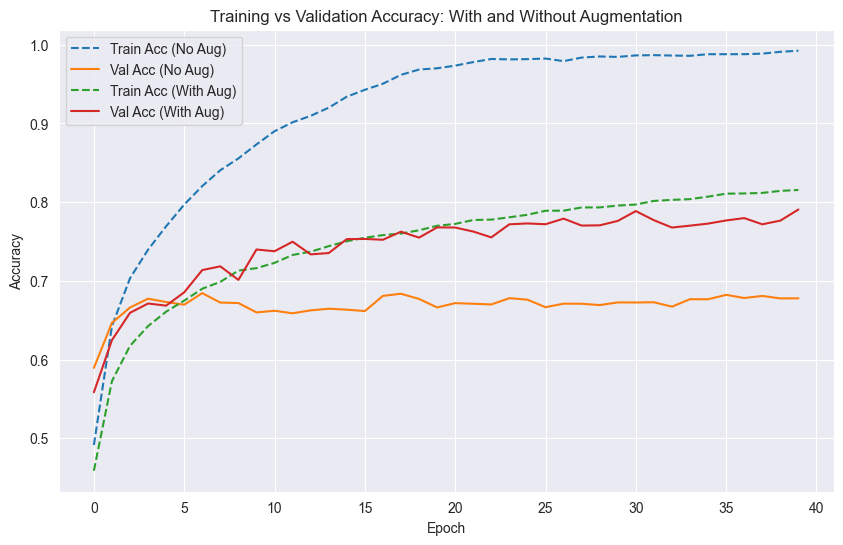

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(history_no_aug.history['accuracy'], label='Train Acc (No Aug)', linestyle='--')
plt.plot(history_no_aug.history['val_accuracy'], label='Val Acc (No Aug)')
plt.plot(history_aug.history['accuracy'], label='Train Acc (With Aug)', linestyle='--')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc (With Aug)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy: With and Without Augmentation')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# without augmentation
train_acc_no_aug = history_no_aug.history['accuracy'][-1]
val_acc_no_aug = history_no_aug.history['val_accuracy'][-1]
gap_no_aug = train_acc_no_aug - val_acc_no_aug

# with augmentation
train_acc_aug = history_aug.history['accuracy'][-1]
val_acc_aug = history_aug.history['val_accuracy'][-1]
gap_aug = train_acc_aug - val_acc_aug

print(f"Without Augmentation -- Train:{train_acc_no_aug:} -- Validation:{val_acc_no_aug:} -- Gap:{gap_no_aug:}")
print(f"With Augmentation -- Train:{train_acc_aug} -- Validation:{val_acc_aug:} -- Gap:{gap_aug:}")
print("Model with smaller gap overfits less:")
if (gap_aug > gap_no_aug):
    print("Without Augmentation")
else:
    print("With Augmentation")


Without Augmentation -- Train:0.9922749996185303 -- Validation:0.6777999997138977 -- Gap:0.31447499990463257
With Augmentation -- Train:0.8154249787330627 -- Validation:0.7906000018119812 -- Gap:0.024824976921081543
Model with smaller gap overfits less:
With Augmentation
